# AAAIM Evaluation Test - UniProt

This notebook tests both single model evaluation and batch evaluation of multiple models.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model
from utils.evaluation import (
    evaluate_single_model,
    evaluate_models_in_folder,
    print_evaluation_results,
    compare_results
)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# LLM configuration
# llm_model = "meta-llama/llama-3.3-70b-instruct:free"  # or "gpt-4o-mini"
llm_model = "Llama-3.3-70B-Instruct"

# Evaluation parameters
max_entities_per_model = 10  # Limit entities per model for testing
num_models_to_test = 5  # Number of models to test in batch evaluation

# Entity and database configuration
entity_type = "protein"
database = "uniprot"
tax_id = 9606

output_dir = "./results/"  # Output directory for results

## BioModels

In [3]:
model_dir = '/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels_251106/'

# Check if model directory exists
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.xml')]
    print(f"✓ Model directory found: {model_dir}")
    print(f"  - Found {len(model_files)} SBML files")
    # print(f"  - Will test first {min(num_models_to_test, len(model_files))} models")

✓ Model directory found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels_251106/
  - Found 1075 SBML files


In [6]:
# Run batch evaluation 
batch_results_df = evaluate_models_in_folder(
    model_dir=model_dir,
    llm_model="gpt-5-mini-2025-08-07",
    top_k=3,
    method="rag",
    entity_type=entity_type,
    database=database,
    save_llm_results=True,
    output_dir=output_dir,
    output_file="biomd251106_uniprot_rag_gpt-5-mini_top3_9606.csv",
    start_at=1,
    tax_id = 9606,
    # chunk_size=20,
    # max_try=3,
    # rate_limit_rpm=10
)

Rate limiting enabled: max 10 LLM requests per minute
LLM results will be saved to: ./results/gpt-5-mini-2025-08-07/protein/20260328_2352
Saved configuration to ./results/gpt-5-mini-2025-08-07/protein/20260328_2352/config.txt
Evaluating 1/1075: BIOMD0000000001.xml
Evaluating 2/1075: BIOMD0000000002.xml
Evaluating 3/1075: BIOMD0000000003.xml
Evaluating 4/1075: BIOMD0000000004.xml
Evaluating 5/1075: BIOMD0000000005.xml
Evaluating 6/1075: BIOMD0000000006.xml
Evaluating 7/1075: BIOMD0000000007.xml
Evaluating 8/1075: BIOMD0000000008.xml
Evaluating 9/1075: BIOMD0000000009.xml
Evaluating 10/1075: BIOMD0000000010.xml
Evaluating 11/1075: BIOMD0000000011.xml
Evaluating 12/1075: BIOMD0000000012.xml
Evaluating 13/1075: BIOMD0000000013.xml
Evaluating 14/1075: BIOMD0000000014.xml
Evaluating 15/1075: BIOMD0000000015.xml
Evaluating 16/1075: BIOMD0000000016.xml
Evaluating 17/1075: BIOMD0000000017.xml
Evaluating 18/1075: BIOMD0000000018.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/202

2026-03-29 01:39:02,753 - WARNING - Species 's28': Found bqmodel qualifier instead of bqbiol - incorrect usage
2026-03-29 01:39:02,755 - WARNING - Species 'Ligand2': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000575.txt
Evaluating 576/1075: BIOMD0000000576.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000576.txt
Evaluating 577/1075: BIOMD0000000577.xml
Evaluating 578/1075: BIOMD0000000578.xml
Evaluating 579/1075: BIOMD0000000579.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000579.txt
Evaluating 580/1075: BIOMD0000000580.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000580.txt
Evaluating 581/1075: BIOMD0000000581.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000581.txt
Evaluating 582/1075: BIOMD0000000582.xml


2026-03-29 01:43:09,700 - WARNING - Species 'GSH': Found bqmodel qualifier instead of bqbiol - incorrect usage
2026-03-29 01:43:09,701 - WARNING - Species 'H2O2': Found bqmodel qualifier instead of bqbiol - incorrect usage
2026-03-29 01:43:09,758 - WARNING - Species 'Grb2': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000582.txt
Evaluating 583/1075: BIOMD0000000583.xml
Evaluating 584/1075: BIOMD0000000584.xml
Evaluating 585/1075: BIOMD0000000585.xml
Evaluating 586/1075: BIOMD0000000586.xml
Evaluating 587/1075: BIOMD0000000587.xml
Evaluating 588/1075: BIOMD0000000588.xml
Evaluating 589/1075: BIOMD0000000589.xml
Evaluating 590/1075: BIOMD0000000590.xml
Evaluating 591/1075: BIOMD0000000591.xml
Evaluating 592/1075: BIOMD0000000592.xml
Evaluating 593/1075: BIOMD0000000593.xml
Evaluating 594/1075: BIOMD0000000594.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000594.txt
Evaluating 595/1075: BIOMD0000000595.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000595.txt
Evaluating 596/1075: BIOMD0000000596.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000596.txt
Evaluating 597/1075: BIOMD0000000597.xml
Evaluatin

...

LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000968.txt
Evaluating 967/1075: BIOMD0000000969.xml
Evaluating 968/1075: BIOMD0000000970.xml
Evaluating 969/1075: BIOMD0000000971.xml
Evaluating 970/1075: BIOMD0000000972.xml
Evaluating 971/1075: BIOMD0000000973.xml
Evaluating 972/1075: BIOMD0000000974.xml
Evaluating 973/1075: BIOMD0000000975.xml


2026-03-29 02:30:03,170 - WARNING - Species 'pS2_pS2_pS2_n': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000975.txt
Evaluating 974/1075: BIOMD0000000976.xml
Evaluating 975/1075: BIOMD0000000977.xml
Evaluating 976/1075: BIOMD0000000978.xml
Evaluating 977/1075: BIOMD0000000979.xml
Evaluating 978/1075: BIOMD0000000980.xml
Evaluating 979/1075: BIOMD0000000981.xml
Evaluating 980/1075: BIOMD0000000982.xml
Evaluating 981/1075: BIOMD0000000983.xml
Evaluating 982/1075: BIOMD0000000984.xml
Evaluating 983/1075: BIOMD0000000985.xml
Evaluating 984/1075: BIOMD0000000986.xml
Evaluating 985/1075: BIOMD0000000987.xml
Evaluating 986/1075: BIOMD0000000988.xml
Evaluating 987/1075: BIOMD0000000989.xml


2026-03-29 02:30:32,367 - WARNING - Species 'pS2_pS2_pS2_n': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000989.txt
Evaluating 988/1075: BIOMD0000000990.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000990.txt
Evaluating 989/1075: BIOMD0000000991.xml
Evaluating 990/1075: BIOMD0000000994.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000994.txt
Evaluating 991/1075: BIOMD0000000995.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000995.txt
Evaluating 992/1075: BIOMD0000000996.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000996.txt
Evaluating 993/1075: BIOMD0000000997.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000997.txt
Evaluating 994/1075: BIOMD0000000998.xml
LLM results saved to: results/gpt-5-mini-2025-08-07/protein/20260328_2352/BIOMD0000000998.txt
Evaluating 995/1075: BIOMD0000000999.xml
LLM results sa

In [7]:
print_evaluation_results(output_dir + "biomd251106_uniprot_rag_gpt-5-mini_top3_9606.csv", ref_results_csv = None, bqbiol_qualifiers=['is', 'isVersionOf'])

Showing all results
Filtering results by qualifiers: ['is', 'isVersionOf']
Number of models assessed: 273
Number of models with predictions: 273
Number of annotations evaluated: 2816
NA rate for synonyms_LLM: 0.005
UNK rate for synonyms_LLM: 0.0
--------------------------------
Per-model statistics:
Average accuracy (per model): 0.916
Ave. recall (formula): 0.914
Ave. precision (formula): 0.329
Ave. recall (exact): 0.914
Ave. precision (exact): 0.329
--------------------------------
Per-species statistics:
Average accuracy (per species): 0.91
Ave. recall (formula, per species): 0.906
Ave. precision (formula, per species): 0.337
Ave. recall (exact, per species): 0.906
Ave. precision (exact, per species): 0.337
--------------------------------
Time:
Ave. total time (per model): 33.679
Ave. total time (per element, per model): 3.265
Ave. LLM time (per model): 33.226
Ave. LLM time (per element, per model): 3.221
Average number of predictions per species: 2.898


In [9]:
print_evaluation_results(output_dir + "biomd251106_uniprot_rag_gpt-5-mini_top3_9606.csv", ref_results_csv = None, bqbiol_qualifiers=['hasPart'])

Showing all results
Filtering results by qualifiers: ['hasPart']
Number of models assessed: 185
Number of models with predictions: 185
Number of annotations evaluated: 2015
NA rate for synonyms_LLM: 0.011
UNK rate for synonyms_LLM: 0.0
--------------------------------
Per-model statistics:
Average accuracy (per model): 0.869
Ave. recall (formula): 0.741
Ave. precision (formula): 0.507
Ave. recall (exact): 0.741
Ave. precision (exact): 0.507
--------------------------------
Per-species statistics:
Average accuracy (per species): 0.846
Ave. recall (formula, per species): 0.703
Ave. precision (formula, per species): 0.488
Ave. recall (exact, per species): 0.703
Ave. precision (exact, per species): 0.488
--------------------------------
Time:
Ave. total time (per model): 41.718
Ave. total time (per element, per model): 3.83
Ave. LLM time (per model): 41.125
Ave. LLM time (per element, per model): 3.776
Average number of predictions per species: 2.952


In [5]:
print_evaluation_results(output_dir + "biomd251106_uniprot_rag_gpt-5-mini_top10_9606.csv", ref_results_csv = None, bqbiol_qualifiers=['is', 'isVersionOf'])

Showing all results
Filtering results by qualifiers: ['is', 'isVersionOf']
Number of models assessed: 273
Number of models with predictions: 273
Number of annotations evaluated: 2816
NA rate for synonyms_LLM: 0.003
UNK rate for synonyms_LLM: 0.0
--------------------------------
Per-model statistics:
Average accuracy (per model): 0.939
Ave. recall (formula): 0.939
Ave. precision (formula): 0.101
Ave. recall (exact): 0.939
Ave. precision (exact): 0.101
--------------------------------
Per-species statistics:
Average accuracy (per species): 0.938
Ave. recall (formula, per species): 0.937
Ave. precision (formula, per species): 0.104
Ave. recall (exact, per species): 0.937
Ave. precision (exact, per species): 0.104
--------------------------------
Time:
Ave. total time (per model): 47.25
Ave. total time (per element, per model): 4.581
Ave. LLM time (per model): 46.484
Ave. LLM time (per element, per model): 4.506
Average number of predictions per species: 9.666


In [10]:
print_evaluation_results(output_dir + "biomd251106_uniprot_rag_gpt-5-mini_top10_9606.csv", ref_results_csv = None, bqbiol_qualifiers=['hasPart'])

Showing all results
Filtering results by qualifiers: ['hasPart']
Number of models assessed: 185
Number of models with predictions: 185
Number of annotations evaluated: 2015
NA rate for synonyms_LLM: 0.003
UNK rate for synonyms_LLM: 0.0
--------------------------------
Per-model statistics:
Average accuracy (per model): 0.935
Ave. recall (formula): 0.871
Ave. precision (formula): 0.185
Ave. recall (exact): 0.871
Ave. precision (exact): 0.185
--------------------------------
Per-species statistics:
Average accuracy (per species): 0.923
Ave. recall (formula, per species): 0.854
Ave. precision (formula, per species): 0.192
Ave. recall (exact, per species): 0.854
Ave. precision (exact, per species): 0.192
--------------------------------
Time:
Ave. total time (per model): 57.383
Ave. total time (per element, per model): 5.268
Ave. LLM time (per model): 56.447
Ave. LLM time (per element, per model): 5.182
Average number of predictions per species: 9.871


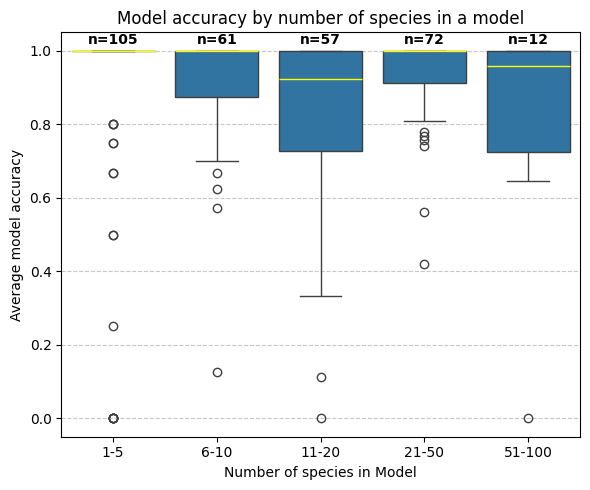

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
results_llama = pd.read_csv('results/biomd251106_uniprot_rag_gpt-5-mini_top3_9606.csv')
# Group models by number of species and calculate accuracy statistics
model_species_count = results_llama.groupby('model').size().reset_index(name='species_count')
model_accuracy = results_llama.groupby('model')['accuracy'].mean().reset_index()

# Merge the two dataframes
model_stats = pd.merge(model_species_count, model_accuracy, on='model')

# Create bins for species count to make the box plot more readable
bins = [0, 5, 10, 20, 50, 100]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100']
model_stats['species_count_bin'] = pd.cut(model_stats['species_count'], bins=bins, labels=labels)

# Count number of models in each bin
bin_counts = model_stats['species_count_bin'].value_counts().reindex(labels, fill_value=0)

# Create the box plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(x='species_count_bin', y='accuracy', data=model_stats, medianprops={"color": "yellow", "linewidth": 1})

# Add counts above each box
for i, label in enumerate(labels):
    count = bin_counts[label]
    ax.text(i, 1.01, f'n={count}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.title('Model accuracy by number of species in a model')
plt.xlabel('Number of species in Model')
plt.ylabel('Average model accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'biomd_uniprot_direct_llama-3_top3_9606.png'), dpi=300, bbox_inches='tight')
plt.show()

## BioDivine
### Single Model Evaluation

In [2]:
test_model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/116_HMOX1-PATHWAY_source.sbml"
tax_id = 9606
# Check if test model exist

if os.path.exists(test_model_file):
    print(f"✓ Test model found: {test_model_file}")
else:
    print(f"✗ Test model not found: {test_model_file}")

✓ Test model found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/116_HMOX1-PATHWAY_source.sbml


In [3]:
from core.model_info import format_prompt, find_species_with_annotations_and_qualifiers
# extract species that have uniprot annotation
existing_annotations, qualifiers = find_species_with_annotations_and_qualifiers(test_model_file, 'uniprot')
existing_annotations

2025-11-30 14:26:47,966 - WARNING - Qualitative species 'csa8': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:26:47,966 - WARNING - Qualitative species 'csa10': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:26:47,967 - WARNING - Qualitative species 'csa32': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:26:47,969 - WARNING - Qualitative species 'sa190': Found bqmodel qualifier instead of bqbiol - incorrect usage


{'csa5': ['P13196', 'P22557'],
 'csa8': ['Q14145', 'Q15843', 'Q13618', 'P62877', 'Q16236'],
 'csa10': ['Q14145', 'Q15843', 'Q13618', 'P62877', 'Q16236', 'P0CG48'],
 'csa12': ['P00450', 'Q9NP59'],
 'csa13': ['Q53TN4'],
 'csa14': ['P13716'],
 'csa19': ['Q13618', 'P62877'],
 'csa22': ['Q9BQS7', 'Q9NP59'],
 'csa27': ['P02787', 'P02786'],
 'csa29': ['P02787', 'P02786'],
 'csa30': ['P02787', 'P02786'],
 'csa31': ['P02787', 'P02786'],
 'csa32': ['Q14145', 'Q15843', 'Q13618', 'P62877', 'Q16236', 'P0CG48'],
 'csa15': ['P08397'],
 'csa74': ['Q9H3M7', 'Q96P20'],
 'csa72': ['P08238', 'Q96P20', 'Q9Y2Z0'],
 'csa101': ['P19838', 'Q04206', 'Q00653'],
 'csa21': ['P53004'],
 'csa69': ['P10599', 'Q9H3M7'],
 'csa83': ['O15553', 'O43586'],
 'csa88': ['O15553', 'Q9ULZ3'],
 'csa85': ['O15553'],
 'csa78': ['P29466', 'Q9ULZ3'],
 'csa11': ['P02794'],
 'csa3': ['P02768'],
 'csa93': ['P29466'],
 'csa94': ['P29466'],
 'csa17': ['P50336'],
 'sa5': ['O75444'],
 'sa6': ['Q16236'],
 'sa29': ['P09601'],
 'sa30': ['Q9Y5

In [4]:
# get the prompt for this model
prompt = format_prompt(test_model_file, existing_annotations.keys(), 'protein')
print(prompt)

Now annotate these:
Protein to annotate: csa5, csa8, csa10, csa12, csa13, csa14, csa19, csa22, csa27, csa29, csa30, csa31, csa32, csa15, csa74, csa72, csa101, csa21, csa69, csa83, csa88, csa85, csa78, csa11, csa3, csa93, csa94, csa17, sa5, sa6, sa29, sa30, sa36, sa39, sa43, sa44, sa53, sa78, sa112, sa114, sa118, sa164, sa167, sa169, sa189, sa3, sa196, sa198, sa214, sa241, sa243, sa362, sa363, sa364, sa366, sa375, sa377, sa381, sa382, sa385, sa460, sa461, sa462, sa463, sa464, sa465, sa466, sa467, sa469, sa471, sa495
Model: "model_id"
// Display Names:
csa83:"PSTPIP1 trimer:Pyrin trimer_complex"; sa70:"CO2_simple_molecule_mitochondrial matrix"; sa39:"ABCC1"; csa32:"Ubiquitin Ligase Complex_complex_cell"; csa88:"Pyrin trimer:ASC_complex"; sa53:"FECH"; sa204:"ADP_simple_molecule"; sa189:"CAND1"; sa158:"H2O_simple_molecule_default_compartment"; sa27:"NADP+_simple_molecule"; sa241:"MCOLN1"; sa138:"Fe3+_ion_default_compartment"; sa71:"CoA-SH_simple_molecule"; sa105:"HMBL_simple_molecule"; sa1

In [3]:
# Test with a single model
recommendations_df, metrics = annotate_model(
    model_file=test_model_file,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    tax_id=tax_id
)

2025-08-18 15:25:00,918 - INFO - Starting annotation for model: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/119_JNK-PATHWAY_source.sbml
2025-08-18 15:25:00,919 - INFO - Using LLM model: Llama-3.3-70B-Instruct
2025-08-18 15:25:00,919 - INFO - Using method: direct for database search
2025-08-18 15:25:00,919 - INFO - Entity type: protein, Database: uniprot
2025-08-18 15:25:00,920 - INFO - Using organism-specific search for tax_id: 9606
2025-08-18 15:25:00,920 - INFO - >>>Step 1: Getting species from model...<<<
2025-08-18 15:25:00,929 - INFO - Found 19 species in model
2025-08-18 15:25:00,939 - INFO - Found 4 entities with existing annotations
2025-08-18 15:25:00,939 - INFO - Annotate all 19 entities
2025-08-18 15:25:00,939 - INFO - >>>Step 2: Extracting model context...<<<
2025-08-18 15:25:00,970 - INFO - Extracted context for model: model_id
2025-08-18 15:25:00,970 - INFO - >>>Step 3: Querying LLM (Llama-3.3-70B-Instruct)...<<<
2025-08-18 15:25:26,233 - INFO - HTTP Request: POST

In [5]:
result_df = evaluate_single_model(
    model_file=test_model_file,
    tax_id=tax_id,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=False,
    output_dir=output_dir
)

2025-11-30 14:27:05,505 - INFO - Evaluating model: 116_HMOX1-PATHWAY_source.sbml
2025-11-30 14:27:05,506 - INFO - Using organism-specific search for tax_id: 9606
2025-11-30 14:27:05,571 - WARNING - Qualitative species 'csa8': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:27:05,572 - WARNING - Qualitative species 'csa10': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:27:05,572 - WARNING - Qualitative species 'csa32': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:27:05,574 - WARNING - Qualitative species 'sa190': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-11-30 14:27:05,588 - INFO - Evaluating 68 entities in 116_HMOX1-PATHWAY_source.sbml
2025-11-30 14:27:05,588 - INFO - Breaking 116_HMOX1-PATHWAY_source.sbml into 68 species into chunks of 50
2025-11-30 14:27:05,588 - INFO - Processing chunk 1/2 (50 species)
2025-11-30 14:27:12,855 - INFO - HTTP Request: POST https://api.llama.com/com

In [6]:
result_df

,model,species_id,display_name,detected_entity_type,synonyms_LLM,reason,exist_annotation_id,exist_annotation_name,predictions,predictions_names,...,precision_formula,recall_exact,precision_exact,accuracy,total_time,llm_time,query_time,tax_id,tax_name,qualifier
0,116_HMOX1-PATHWAY_source.sbml,csa5,ALAS1:ALAS2_complex,protein,"[ALAS1, ALAS2]",Chunk 1: Most of the proteins are identified b...,"[P13196, P22557]","ALAS1, ALAS2","[P13196, P22557]","ALAS1, ALAS2",...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,"isEncodedBy, isEncodedBy"
1,116_HMOX1-PATHWAY_source.sbml,csa8,Ubiquitin Ligase Complex_complex_cell,protein,"[CUL1, CUL2, CUL3]",,"[Q14145, Q15843, Q13618, P62877, Q16236]","KEAP1, NEDD8, CUL3, RBX1, NFE2L2","[Q13616, Q13617, Q13618]","CUL1, CUL2, CUL3",...,0,0.200000,0.333333,1,10.91736,10.368202,0.549158,9606,None,"isEncodedBy, isEncodedBy, isEncodedBy, isEncod..."
2,116_HMOX1-PATHWAY_source.sbml,csa10,Ubiquitin Ligase Complex_complex_cell,protein,"[CUL1, CUL2, CUL3]",,"[Q14145, Q15843, Q13618, P62877, Q16236, P0CG48]","KEAP1, NEDD8, CUL3, RBX1, NFE2L2, UBC","[Q13616, Q13617, Q13618]","CUL1, CUL2, CUL3",...,0,0.166667,0.333333,1,10.91736,10.368202,0.549158,9606,None,"isEncodedBy, isEncodedBy, isEncodedBy, isEncod..."
3,116_HMOX1-PATHWAY_source.sbml,csa12,SLC40A1:CP:Cu2+_complex,protein,"[SLC40A1, CP, HEPH]",,"[P00450, Q9NP59]","CP, SLC40A1","[Q9NP59, P00450, Q9BQS7]","SLC40A1, CP, HEPH",...,0,1.000000,0.666667,1,10.91736,10.368202,0.549158,9606,None,"isEncodedBy, isEncodedBy"
4,116_HMOX1-PATHWAY_source.sbml,csa13,CYBRD1:Heme_complex,protein,[CYBRD1],,[Q53TN4],CYBRD1,[Q53TN4],CYBRD1,...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,isEncodedBy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,116_HMOX1-PATHWAY_source.sbml,sa464,IL-1B_cell,protein,"[IL1B, INTERLEUKIN 1 BETA]",,[P01584],IL1B,[P01584],IL1B,...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,isEncodedBy
64,116_HMOX1-PATHWAY_source.sbml,sa465,IL-18_cell,protein,"[IL18, INTERLEUKIN 18]",,[Q14116],IL18,[Q14116],IL18,...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,isEncodedBy
65,116_HMOX1-PATHWAY_source.sbml,sa466,IL-1B_default_compartment,protein,"[IL1B, INTERLEUKIN 1 BETA]",,[P01584],IL1B,[P01584],IL1B,...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,isEncodedBy
66,116_HMOX1-PATHWAY_source.sbml,sa467,IL-18_default_compartment,protein,"[IL18, INTERLEUKIN 18]",,[Q14116],IL18,[Q14116],IL18,...,0,1.000000,1.000000,1,10.91736,10.368202,0.549158,9606,None,isEncodedBy


### Batch Model Evaluation

In [2]:
model_dir = '/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/'

# Check if model directory exists
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.sbml')]
    print(f"✓ Model directory found: {model_dir}")
    print(f"  - Found {len(model_files)} SBML files")

✓ Model directory found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/
  - Found 190 SBML files


In [3]:
# Run batch evaluation 
batch_results_df = evaluate_models_in_folder(
    model_dir=model_dir,
    llm_model=llm_model,
    top_k=3,
    entity_type=entity_type,
    database=database,
    save_llm_results=True,
    output_dir=output_dir,
    output_file="biodivine_uniprot_direct_llama-3_top3_9606_update_prompt.csv",
    start_at=1,
    tax_id = 9606
)

2025-12-03 13:45:26,366 - WARNING - Skipping 001_SIGNALING-IN-MACROPHAGE-ACTIVATION_source.sbml - no results generated


LLM results will be saved to: ./results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345
Saved configuration to ./results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/config.txt
Evaluating 1/190: 001_SIGNALING-IN-MACROPHAGE-ACTIVATION_source.sbml
Evaluating 2/190: 002_SIGNAL-TRANSDUCTION-IN-FIBROBLASTS_source.sbml


2025-12-03 13:45:26,527 - WARNING - Skipping 002_SIGNAL-TRANSDUCTION-IN-FIBROBLASTS_source.sbml - no results generated
2025-12-03 13:45:26,541 - WARNING - Skipping 003_MAMMALIAN-CELL-CYCLE_source.sbml - no results generated
2025-12-03 13:45:26,798 - WARNING - Skipping 004_ERBB-RECEPTOR-SIGNALING_source.sbml - no results generated


Evaluating 3/190: 003_MAMMALIAN-CELL-CYCLE_source.sbml
Evaluating 4/190: 004_ERBB-RECEPTOR-SIGNALING_source.sbml


2025-12-03 13:45:26,817 - WARNING - Skipping 005_FA-BRCA-PATHWAY_source.sbml - no results generated
2025-12-03 13:45:26,846 - WARNING - Skipping 006_HGF-SIGNALING-IN-KERATINOCYTES_source.sbml - no results generated
2025-12-03 13:45:26,851 - WARNING - Skipping 007_CORTICAL-AREA-DEVELOPMENT_source.sbml - no results generated
2025-12-03 13:45:26,866 - WARNING - Skipping 008_DEATH-RECEPTOR-SIGNALING_source.sbml - no results generated
2025-12-03 13:45:26,896 - WARNING - Skipping 009_YEAST-APOPTOSIS_source.sbml - no results generated
2025-12-03 13:45:26,906 - WARNING - Skipping 010_CARDIAC-DEVELOPMENT_source.sbml - no results generated
2025-12-03 13:45:26,927 - WARNING - Skipping 011_GUARD-CELL-ABSCISIC-ACID-SIGNALING_source.sbml - no results generated
2025-12-03 13:45:26,969 - WARNING - Skipping 012_T-CELL-RECEPTOR-SIGNALING_source.sbml - no results generated
2025-12-03 13:45:26,985 - WARNING - Skipping 013_CHOLESTEROL-REGULATORY-PATHWAY_source.sbml - no results generated
2025-12-03 13:45:2

...

LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/215_MTOR-PATHWAY_source.txt
Evaluating 187/190: 216_PPARGC1A-PATHWAY_source.sbml
LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/216_PPARGC1A-PATHWAY_source.txt
Evaluating 188/190: 217_PRKN-PATHWAY_source.sbml


2025-12-03 13:48:42,317 - WARNING - Qualitative species 'sa11980': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-12-03 13:48:42,318 - WARNING - Qualitative species 'sa11929': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/217_PRKN-PATHWAY_source.txt
Evaluating 189/190: 218_TCA-CYCLE_source.sbml


2025-12-03 13:48:47,528 - WARNING - Qualitative species 'sa9528': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-12-03 13:48:47,529 - WARNING - Qualitative species 'sa9522': Found bqmodel qualifier instead of bqbiol - incorrect usage
2025-12-03 13:48:47,531 - WARNING - Qualitative species 'sa11173': Found bqmodel qualifier instead of bqbiol - incorrect usage


LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/218_TCA-CYCLE_source.txt
Evaluating 190/190: 219_WNT-PI3K-AKT-PATHWAY_source.sbml
LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20251203_1345/219_WNT-PI3K-AKT-PATHWAY_source.txt


In [4]:
print_evaluation_results(output_dir + "biodivine_uniprot_direct_llama-3_top3_9606_update_prompt.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.89
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.87
Ave. precision (exact): 0.78
Average accuracy (per species): 0.92
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.90
Ave. precision (exact, per species): 0.82
Ave. total time (per model): 14.23
Ave. total time (per element, per model): 0.36
Ave. LLM time (per model): 13.93
Ave. LLM time (per element, per model): 0.35
Average number of predictions per species: 1.33


In [9]:
print_evaluation_results(output_dir + "biodivine_uniprot_direct_llama-3_top3_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.88
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.85
Ave. precision (exact): 0.72
Average accuracy (per species): 0.91
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.88
Ave. precision (exact, per species): 0.72
Ave. total time (per model): 16.49
Ave. total time (per element, per model): 0.42
Ave. LLM time (per model): 16.20
Ave. LLM time (per element, per model): 0.41
Average number of predictions per species: 1.59


In [7]:
print_evaluation_results("prev_results/biodivine_uniprot_direct_llama-3_top3_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.91
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.89
Ave. precision (exact): 0.65
Average accuracy (per species): 0.94
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.91
Ave. precision (exact, per species): 0.66
Ave. total time (per model): 19.09
Ave. total time (per element, per model): 0.48
Ave. LLM time (per model): 18.72
Ave. LLM time (per element, per model): 0.47
Average number of predictions per species: 1.85


In [10]:
df1 = pd.read_csv('prev_results/biodivine_uniprot_direct_llama-3_top3_9606.csv')
df2 = pd.read_csv('results/biodivine_uniprot_direct_llama-3_top3_9606.csv')

# Merge on model and species_id, suffixing accuracy columns
merged = pd.merge(
    df1[['model', 'species_id', 'accuracy']],
    df2[['model', 'species_id', 'accuracy']],
    on=['model', 'species_id'],
    suffixes=('_1', '_2')
)

# Find rows where accuracy differs (including NaN vs value)
diffs = merged[
    (merged['accuracy_1'] != merged['accuracy_2']) |
    (merged['accuracy_1'].isnull() != merged['accuracy_2'].isnull())
]

# Print the differing model/species_id pairs
for _, row in diffs.iterrows():
    print(f"model: {row['model']}, species_id: {row['species_id']}, accuracy_1: {row['accuracy_1']}, accuracy_2: {row['accuracy_2']}")

model: 116_HMOX1-PATHWAY_source.sbml, species_id: csa101, accuracy_1: 1, accuracy_2: 0
model: 116_HMOX1-PATHWAY_source.sbml, species_id: csa85, accuracy_1: 1, accuracy_2: 0
model: 116_HMOX1-PATHWAY_source.sbml, species_id: csa11, accuracy_1: 1, accuracy_2: 0
model: 116_HMOX1-PATHWAY_source.sbml, species_id: csa3, accuracy_1: 1, accuracy_2: 0
model: 116_HMOX1-PATHWAY_source.sbml, species_id: sa164, accuracy_1: 0, accuracy_2: 1
model: 116_HMOX1-PATHWAY_source.sbml, species_id: sa3, accuracy_1: 0, accuracy_2: 1
model: 116_HMOX1-PATHWAY_source.sbml, species_id: sa364, accuracy_1: 0, accuracy_2: 1
model: 116_HMOX1-PATHWAY_source.sbml, species_id: sa366, accuracy_1: 0, accuracy_2: 1
model: 120_KYNURENINE-PATHWAY_source.sbml, species_id: csa36, accuracy_1: 1, accuracy_2: 0
model: 120_KYNURENINE-PATHWAY_source.sbml, species_id: sa26, accuracy_1: 1, accuracy_2: 0
model: 120_KYNURENINE-PATHWAY_source.sbml, species_id: sa30, accuracy_1: 1, accuracy_2: 0
model: 120_KYNURENINE-PATHWAY_source.sbml, 

In [ ]:
print_evaluation_results(output_dir + "biodivine_uniprot_direct_llama-3_top5_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.92
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.88
Ave. precision (exact): 0.65
Average accuracy (per species): 0.94
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.91
Ave. precision (exact, per species): 0.67
Ave. total time (per model): 22.02
Ave. total time (per element, per model): 0.56
Ave. LLM time (per model): 21.66
Ave. LLM time (per element, per model): 0.55
Average number of predictions per species: 1.86


## Functions test

In [12]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging
import libsbml

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model, model_info

In [13]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml"
entity_type = "protein"
species_ids = model_info.get_all_species_ids(model_file, entity_type)
print(species_ids)
model_info.extract_model_info(model_file, species_ids, entity_type)

['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'x56', 'x57', 'x58', 'x59', 'x60', 'x61', 'x62', 'x63', 'x64', 'x65', 'x66', 'x67', 'x68', 'x69', 'x70', 'x71', 'x72', 'x73', 'x74', 'x75', 'x76', 'x77', 'x78', 'x79', 'x80', 'x81', 'x82', 'x83', 'x84', 'x85', 'x86', 'x87', 'x88', 'x89', 'x90', 'x91', 'x92', 'x93', 'x94', 'Raf_act', 'Ras_GTP', 'MEK_PP', 'ERK_PP', 'SHC_P_t', 'EGF_EGFR_act']


{'model_name': 'Schoeberl2002 - EGF MAPK',
 'model_type': <ModelType.SBML: 'SBML'>,
 'format_info': {'has_fbc': False,
  'has_qual': False,
  'num_species': 100,
  'num_reactions': 125},
 'display_names': {'x18': 'EGF-EGFRi*^2-GAP-Grb2',
  'x88': 'EGF-EGFR*^2-GAP-Grb2-Sos-Prot',
  'x10': 'EGF-EGFRi',
  'x11': 'EGF-EGFRi^2',
  'x51': 'MEK-PP',
  'x14': 'GAP',
  'x72': 'Rafi*',
  'x48': 'MEK-Raf*',
  'x45': 'Raf*',
  'x81': 'ERKi-P',
  'x89': 'EGF-EGFR*^2-GAP-Grb2-Sos-Ras-GDP-Prot',
  'x40': 'Shc*',
  'x52': "MEK-PP-P'ase2",
  'x68': 'EGF-EGFRi*^2-GAP-Shc*-Grb2-Sos-Ras-GTP',
  'x59': 'ERK-PP',
  'x29': 'EGF-EGFR*^2-GAP-Grb2-Sos-Ras-GTP',
  'x60': 'Phosphotase3',
  'x57': 'ERK-P',
  'x9': 'Proti',
  'Raf_act': 't_Raf*',
  'x32': 'EGF-EGFR*^2-GAP-Shc',
  'x46': "Raf*-P'ase",
  'x31': 'Shc',
  'x16': 'EGFi',
  'x77': 'MEKi-PP',
  'x80': 'ERKi-MEKi-PP',
  'x41': 'Raf',
  'x44': 'Phosphotase1',
  'x28': 'Ras-GTP',
  'x22': 'Grb2',
  'ERK_PP': 't_ERK_PP',
  'x53': 'Phosphatase2',
  'x8': 'EGF-

In [14]:
prompt = model_info.format_prompt(model_file, species_ids, entity_type)
print(prompt)

Now annotate these:
Protein to annotate: x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12, x13, x14, x15, x16, x17, x18, x19, x20, x21, x22, x23, x24, x25, x26, x27, x28, x29, x30, x31, x32, x33, x34, x35, x36, x37, x38, x39, x40, x41, x42, x43, x44, x45, x46, x47, x48, x49, x50, x51, x52, x53, x54, x55, x56, x57, x58, x59, x60, x61, x62, x63, x64, x65, x66, x67, x68, x69, x70, x71, x72, x73, x74, x75, x76, x77, x78, x79, x80, x81, x82, x83, x84, x85, x86, x87, x88, x89, x90, x91, x92, x93, x94, Raf_act, Ras_GTP, MEK_PP, ERK_PP, SHC_P_t, EGF_EGFR_act
Model: "Schoeberl2002 - EGF MAPK"
// Display Names:
x18:"EGF-EGFRi*^2-GAP-Grb2"; x88:"EGF-EGFR*^2-GAP-Grb2-Sos-Prot"; x10:"EGF-EGFRi"; x11:"EGF-EGFRi^2"; x51:"MEK-PP"; x14:"GAP"; x72:"Rafi*"; x48:"MEK-Raf*"; x45:"Raf*"; x81:"ERKi-P"; x89:"EGF-EGFR*^2-GAP-Grb2-Sos-Ras-GDP-Prot"; x40:"Shc*"; x52:"MEK-PP-P'ase2"; x68:"EGF-EGFRi*^2-GAP-Shc*-Grb2-Sos-Ras-GTP"; x59:"ERK-PP"; x29:"EGF-EGFR*^2-GAP-Grb2-Sos-Ras-GTP"; x60:"Phosphotase3"; x57:"ERK-P

In [3]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
entity_type = "protein"
species_ids = model_info.get_all_species_ids(model_file, entity_type)
print(species_ids)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1916', 'csa1897', 'csa1919', 'csa1898', 'csa1902', 'csa1899', 'csa1914', 'csa1949', 'csa1901', 'csa1921', 'csa1910', 'csa1895', 'csa1896', 'sa11864', 'sa12297', 'sa11889', 'sa11857', 'sa11975', 'sa11930', 'sa11896', 'sa11962', 'sa11966', 'sa11863', 'sa12216', 'sa11967', 'sa11923', 'sa11907', 'sa11979', 'sa11856', 'sa11976', 'sa11955', 'sa11883', 'sa11973', 'sa11932', 'sa11855', 'sa11946', 'sa11940', 'sa11935', 'sa11914', 'sa12001', 'sa11881', 'sa12294', 'sa11887', 'sa11945', 'sa11901', 'sa11950', 'sa11922', 'sa11980', 'sa11987', 'sa11852', 'sa11902', 'sa12024', 'sa11871', 'sa11944', 'sa11865', 'sa11867', 'sa12015', 'sa11908', 'sa11854', 'sa11964', 'sa11939', 'sa11938', 'sa12293', 'sa11929', 'sa12295', 'sa11972', 'sa11948', 'sa11927']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 68,
  'num_transitions': 34},
 'display_names': {'csa1910': 'alpha-ketoglutarate_space_dehydrogenase_complex',
  'sa11902': 'H+_ion_mitochondrial_space_matrix',
  'sa12297': 'GP4G_simple_molecule',
  'sa11975': 'NAD(+)_simple_molecule',
  'sa12295': 'GMP_simple_molecule',
  'sa11887': 'FAD_simple_molecule',
  'sa12001': 'Mn2+_ion',
  'csa1914': 'mitochondrial_space_pyruvate_space_carrier_complex',
  'sa11901': 'ACSS1',
  'sa11930': 'ATP_simple_molecule',
  'sa12293': 'NUDT2',
  'sa11945': 'pyruvate_simple_molecule_mitochondrial_space_matrix',
  'sa11938': 'ammonium_simple_molecule',
  'sa11962': 'GLUD1',
  'sa11863': 'GDP_simple_molecule',
  'csa1902': 'isocitrate_space_dehydrogenase_complex',
  'sa11979': 'PC',
  'sa11980': 'acetate_simple_molecule',
  'sa11867': 'SIRT3',
  'sa11927':

In [4]:
prompt = model_info.format_prompt(model_file, species_ids, entity_type)
print(prompt)

Now annotate these:
Protein to annotate: csa1916, csa1897, csa1919, csa1898, csa1902, csa1899, csa1914, csa1949, csa1901, csa1921, csa1910, csa1895, csa1896, sa11864, sa12297, sa11889, sa11857, sa11975, sa11930, sa11896, sa11962, sa11966, sa11863, sa12216, sa11967, sa11923, sa11907, sa11979, sa11856, sa11976, sa11955, sa11883, sa11973, sa11932, sa11855, sa11946, sa11940, sa11935, sa11914, sa12001, sa11881, sa12294, sa11887, sa11945, sa11901, sa11950, sa11922, sa11980, sa11987, sa11852, sa11902, sa12024, sa11871, sa11944, sa11865, sa11867, sa12015, sa11908, sa11854, sa11964, sa11939, sa11938, sa12293, sa11929, sa12295, sa11972, sa11948, sa11927
Model: "model_id" 
// Display Names:
{'csa1910': 'alpha-ketoglutarate_space_dehydrogenase_complex', 'sa11902': 'H+_ion_mitochondrial_space_matrix', 'sa12297': 'GP4G_simple_molecule', 'sa11975': 'NAD(+)_simple_molecule', 'sa12295': 'GMP_simple_molecule', 'sa11887': 'FAD_simple_molecule', 'sa12001': 'Mn2+_ion', 'csa1914': 'mitochondrial_space_pyruv

In [4]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
reader = libsbml.SBMLReader()
document = reader.readSBML(model_file)
model = document.getModel().getPlugin("qual")
model.getPackageName()

'qual'

In [5]:
species_ids = model_info.get_all_species_ids(model_file, entity_type)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1916', 'csa1897', 'csa1919', 'csa1898', 'csa1902', 'csa1899', 'csa1914', 'csa1949', 'csa1901', 'csa1921', 'csa1910', 'csa1895', 'csa1896', 'sa11864', 'sa12297', 'sa11889', 'sa11857', 'sa11975', 'sa11930', 'sa11896', 'sa11962', 'sa11966', 'sa11863', 'sa12216', 'sa11967', 'sa11923', 'sa11907', 'sa11979', 'sa11856', 'sa11976', 'sa11955', 'sa11883', 'sa11973', 'sa11932', 'sa11855', 'sa11946', 'sa11940', 'sa11935', 'sa11914', 'sa12001', 'sa11881', 'sa12294', 'sa11887', 'sa11945', 'sa11901', 'sa11950', 'sa11922', 'sa11980', 'sa11987', 'sa11852', 'sa11902', 'sa12024', 'sa11871', 'sa11944', 'sa11865', 'sa11867', 'sa12015', 'sa11908', 'sa11854', 'sa11964', 'sa11939', 'sa11938', 'sa12293', 'sa11929', 'sa12295', 'sa11972', 'sa11948', 'sa11927']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 68,
  'num_transitions': 34},
 'display_names': {'sa12024': 'pyruvate_simple_molecule_neuron',
  'csa1899': 'Succinyl-CoA_space_ligase_complex_mitochondrial_space_matrix',
  'csa1895': 'pyruvate_space_dehydrogenase_space_complex_complex_mitochondrial_space_matrix',
  'sa11939': 'oxaloacetate(2-)_simple_molecule',
  'csa1897': 'malate_space_dehydrogenase_space_2_complex',
  'sa11889': 'fumaric_space_acid_simple_molecule',
  'sa11962': 'GLUD1',
  'sa12294': 'GTP_simple_molecule',
  'sa11979': 'PC',
  'sa11901': 'ACSS1',
  'sa11987': 'ADHFE1',
  'csa1919': 'fumarate_space_hydratase_complex',
  'sa11927': 'Co2+_ion',
  'sa11863': 'GDP_simple_molecule',
  'sa11883': '(5-hydroxyindol-3-yl)acetaldehyde_simple_molecule',
  'sa11854': '(S)-malate(2-)_simple_molecule',
  'sa11935': 'succinyl-CoA

In [3]:
import os
from openai import OpenAI
client = OpenAI(api_key=os.getenv("LLAMA_API_KEY"),base_url="https://api.llama.com/compat/v1/")
response = client.chat.completions.create(
    model="Llama-3.3-70B-Instruct",
    messages=[
        {"role": "user", "content": "Which planet do humans live on?"}
    ],
    temperature=0.2,
    max_tokens=10000)
print(response.choices[0].message.content)

Humans live on the planet Earth.
